In [2]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../../'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(sys.path)

['/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages', '/content/CellUntangler/', '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler']


In [6]:
# CONVENIENCE: 
import sys as sys

print(sys.path)

# If running notebook outside of scrna_mvae directory, add it to the path
sys.path.append('/content/CellUntangler/')
print(sys.version)

import os

import torch

from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
import numpy as np

import pandas as pd
import scanpy as sc


adata = sc.read_h5ad("/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/data/synthetic/cophaser/synthethic_cc.h5ad")

adata.var["gene_symbols"] = adata.var.index

zonation_genes = np.array(['ANLN', 'ANP32E', 'ATAD2', 'AURKA', 'AURKB', 'BIRC5', 'BLM', 'BRIP1',
       'BUB1', 'CASP8AP2', 'CBX5', 'CCNB2', 'CCNE2', 'CDC20', 'CDC25C',
       'CDC45', 'CDC6', 'CDCA2', 'CDCA3', 'CDCA7', 'CDCA8', 'CDK1', 'CENPA',
       'CENPE', 'CENPF', 'CENPU', 'CHAF1B', 'CKAP2', 'CKAP2L', 'CKAP5',
       'CKS1B', 'CKS2', 'CLSPN', 'CTCF', 'DLGAP5', 'DSCC1', 'DTL', 'E2F8',
       'ECT2', 'ESCO2', 'EXO1', 'G2E3', 'GAS2L3', 'GINS2', 'GMNN', 'GTSE1',
       'HELLS', 'HJURP', 'HMGB2', 'HMMR', 'JPT1', 'KIF11', 'KIF20B', 'KIF23',
       'KIF2C', 'LBR', 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'MKI67', 'MSH2', 'NASP',
       'NCAPD2', 'NDC80', 'NEK2', 'NUF2', 'NUSAP1', 'PCNA', 'PIMREG', 'POLA1',
       'POLD3', 'PRIM1', 'PSRC1', 'RAD51', 'RAD51AP1', 'RANGAP1', 'RFC2',
       'RPA2', 'RRM1', 'RRM2', 'SLBP', 'SMC4', 'TACC3', 'TIPIN', 'TMPO',
       'TOP2A', 'TPX2', 'TTK', 'TUBB4B', 'TYMS', 'UBE2C', 'UBR7', 'UHRF1',
       'UNG', 'USP1', 'WDR76'])

# Genes involved with the zonation present in adata
contained_genes = adata.var["gene_symbols"].isin(zonation_genes)


print(f"Number of zonation genes present in adata: {np.sum(contained_genes)}")

cycle_gene_indices = np.where(contained_genes)[0]
non_cycle_gene_indices = np.where(~contained_genes)[0]
rearranged_indices = np.hstack((cycle_gene_indices, non_cycle_gene_indices))
adata = adata[:, rearranged_indices]
adata.uns["new_gene_ordering"] = rearranged_indices

from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = "e2, e10"
config.seed = 68715
config.init = "custom"
adata.X.todense()

x = adata.X.todense().astype(np.double)
batch = (np.zeros((x.shape[0], 1)) * -1).astype(np.int64)
# y holds the batch vector for the dataset
y = batch

# Create the dataset and separate it into training and test sets
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

# A mask that is 1 where the gene is a cycling gene and 0 otherwise
mask_cyc = np.zeros(adata.n_vars)
mask_cyc[adata.var["gene_symbols"].isin(zonation_genes)] = 1

# A mask that is 0 where the gene is a cycling gene and 1 otherwise
mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(zonation_genes)] = 0

mask = torch.tensor([mask_cyc, mask_all])

'''
'''

['/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages', '/content/CellUntangler/', '/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler', '/content/CellUntangler/', '/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/tmpjzlc_ctl', '/content/CellUntangler/', '/content/CellUntangler/']
3.11.12 (main, Apr  8 2025, 14:15:29) [Clang 16.0.0 (clang-1600.0.26.6)]
Number of zonation genes present in adata: 97


/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_80885/3591422347.py:52: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices


in_dim = 10097
dataset.in_dim = 10097
Dataset seed: 68715


/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_80885/3591422347.py:83: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  mask = torch.tensor([mask_cyc, mask_all])


'\n'

In [7]:
mask

tensor([[1., 1., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 1., 1.]], dtype=torch.float64)

In [8]:
mask_cyc

array([1., 1., 1., ..., 0., 0., 0.])

In [9]:
sinusodial_genes_potentially = adata.X[:,mask_cyc.astype(bool)]

In [10]:
X = sinusodial_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

In [11]:
U.shape

(10000, 97)

In [17]:
adata.var

,gene_symbols
ANLN,ANLN
ANP32E,ANP32E
ATAD2,ATAD2
AURKA,AURKA
AURKB,AURKB
...,...
GENE_10092,GENE_10092
GENE_10093,GENE_10093
GENE_10094,GENE_10094
GENE_10095,GENE_10095


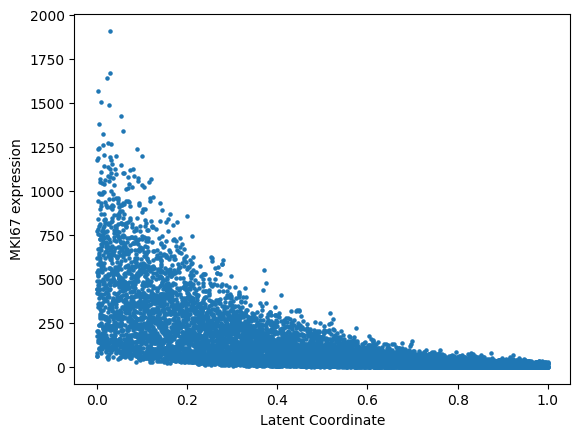

In [19]:
import matplotlib.pyplot as plt
import numpy as np

gene_name = "MKI67"  

# x-axis: S.Score
x = adata.obs['latent_coordinate'].to_numpy().flatten()

# y-axis: expression of the gene (convert sparse column to dense)
gene_idx = np.where(adata.var["gene_symbols"] == gene_name)[0][0]  # get column index
y = adata.X[:, gene_idx].toarray().flatten()  # .toarray() converts sparse to dense

# scatter plot
plt.scatter(x, y, s=5)
plt.xlabel("Latent Coordinate")
plt.ylabel(f"{gene_name} expression")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

gene_name = "MKI67"  

# x-axis: S.Score
x = adata.obs['S.Score'].to_numpy().flatten()

# y-axis: expression of the gene (convert sparse column to dense)
gene_idx = np.where(adata.var["feature_name"] == gene_name)[0][0]  # get column index
y = adata.X[:, gene_idx].toarray().flatten()  # .toarray() converts sparse to dense

# scatter plot
plt.scatter(x, y, s=5)
plt.xlabel("S.Score")
plt.ylabel(f"{gene_name} expression")
plt.show()

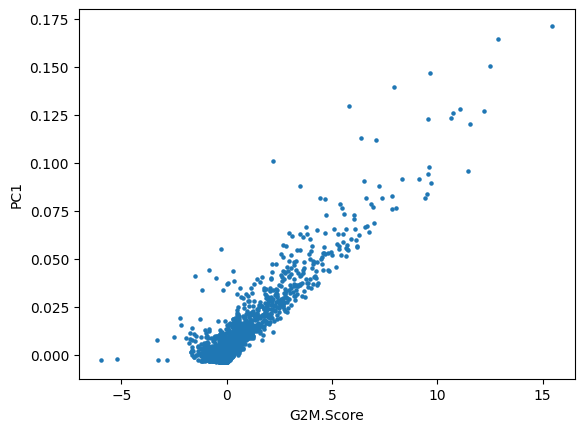

In [33]:
import matplotlib.pyplot as plt

z = adata.obs['G2M.Score'].to_numpy().flatten()

# Make sure y_vals is 1D
y_vals = np.ravel(U[:, 0])  # ravel ensures (10199,) shape

plt.scatter(z, y_vals, s=5)
plt.xlabel("G2M.Score")
plt.ylabel("PC1")
plt.show()

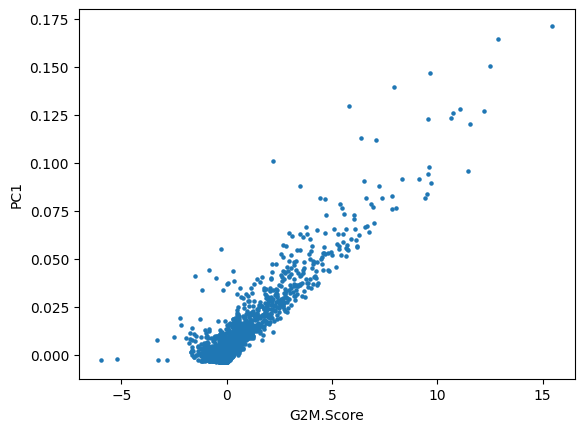

In [10]:
import matplotlib.pyplot as plt

z = adata.obs['G2M.Score'].to_numpy().flatten()

# Make sure y_vals is 1D
y_vals = np.ravel(U[:, 0])  # ravel ensures (10199,) shape

plt.scatter(z, y_vals, s=5)
plt.xlabel("G2M.Score")
plt.ylabel("PC1")
plt.show()

In [11]:
z.shape

(10199,)

In [12]:
y_vals.shape

(10199,)

In [13]:
U[:, 0]

matrix([[-0.00326043],
        [-0.0023664 ],
        [-0.00341562],
        ...,
        [-0.00013472],
        [-0.00263132],
        [-0.00268296]], dtype=float32)

In [14]:
z.shape

(10199,)

In [15]:
U[:, 0].shape

(10199, 1)

In [16]:
z.reshape(-1,1).shape

(10199, 1)

In [17]:
U[:, 0].shape

(10199, 1)

In [18]:
adata.obs.columns

Index(['percent.mt', 'percent.rb', 'doublet', 'author_sample_id', 'S.Score',
       'G2M.Score', 'Phase', 'CC.Diff', 'author_cell_type', 'nCount_RNA',
       'nFeature_RNA', 'doublet_score', 'cell_type_ontology_term_id',
       'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type',
       'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'author_tumor_supersite', 'author_tumor_site',
       'author_tumor_subsite', 'author_sort_parameters', 'author_therapy',
       'author_procedure', 'author_procedure_type', 'is_primary_data',
       'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid'],
      dtype='object')

In [ ]:
# Q: WHEN WORKING WITH REAL CELL CYCLE GENES - WHAT DOES THE 1D PC1 EMBEDDING WITH CELL CYCLE ANNOTATIONS LOOK LIKE? 

In [19]:
adata.X.todense().shape

(10199, 31815)

## Train CellUntangler.

Specify whether to use CPU or GPU.

In [4]:
torch.set_default_dtype(torch.float64)

In [5]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


Below is to save embeddings generated through the epochs. Set visualization_information = None if it is not desired.

In [6]:
# The path to save the intermediate embeddings to
epoch_embeddings_save_path = "./experiments/liver_zonation_repro"
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

In [7]:
adata.obs

,RNA_snn_res.0.8,nCount_RNA,nFeature_RNA,orig.ident,percent.mt,rep,seurat_clusters,time,zonation1
CellID,,,,,,,,,
ZT00B1,3,3287.0,1279,1,15.150593,B,3,T00,0.285488
ZT00B4,7,1397.0,646,1,13.242663,B,7,T00,0.539859
ZT00B5,7,1293.0,615,1,13.689095,B,7,T00,0.485066
ZT00B6,3,1339.0,606,1,21.657954,B,3,T00,0.566012
ZT00B7,3,1712.0,736,1,18.574766,B,3,T00,0.437602
...,...,...,...,...,...,...,...,...,...
ZT18B1782,5,1394.0,716,1,16.427547,B,5,T18,0.745925
ZT18B1783,2,1523.0,691,1,22.127380,B,2,T18,0.444957
ZT18B1784,5,1677.0,786,1,19.260584,B,5,T18,0.500790


In [8]:
mask.shape

torch.Size([2, 14811])

In [9]:
# TODO - train for 500 epochs once verified working!
config.max_epochs = 500
config.epochs = 500

In [10]:
if config.seed:
    print(config.seed)
    torch.manual_seed(config.seed)
    np.random.seed(config.seed)
    np.random.default_rng(config.seed)

model_name = 'e2, e10' # config.model_name
components = utils.parse_components(model_name, config.fixed_curvature)

68715


In [11]:
model_name

'e2, e10'

In [12]:
components

[EuclideanComponent(R^2), EuclideanComponent(R^10)]

In [13]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config,
              component_subspaces=None
                  ).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
EuclideanComponent(R^2)


In [14]:
print(model.component_subspaces)

None


In [16]:
x.dtype

dtype('float64')

In [18]:
y.dtype

dtype('int64')

In [20]:
mask.dtype

torch.float64

In [21]:

# =====
"""
"""

trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)

trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                           visualize_information=visualize_information)

FileNotFoundError: [Errno 2] No such file or directory: './experiments/liver_zonation_repro/e2, e10_all_encode_v63_initialization_z_params.txt'

## Analysis

In [9]:
embeddings_save_path = "./experiments/liver_zonation_repro"
a = trainer.model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'), a[4].detach().to(torch.device("cpu")).numpy())

In [10]:
gene_expression_matrix_path = "./experiments/liver_zonation_repro"

In [11]:
import torch.nn as nn
# Encode the batch vector which must also be passed to the decoder
batch = nn.functional.one_hot(torch.tensor(y[:,0]), 1).to(config.device)
library_size = torch.sum(torch.tensor(x), dim=1).to(config.device)

In [12]:
# To enhance zonation, mask the non-zonation latent representation and pass it to the decoder
# The latent representations have a dimension of 12 (2 dimensions for zonation + 10 dimensions for non-zonation)
z1_mask = torch.zeros(12, device=config.device)
z1_mask[0:2] = 1

z_params = a[4].detach()
x_z1_params_mu = trainer.model.decode(z_params*z1_mask, batch)[0]
x_z1_params_mu = x_z1_params_mu * library_size[:, None] 
# Q: Why does the library_size (RNA expression of each cell (?)) need to be considered 
#    when re-deriving the latent variable values of z1? 
np.savetxt(os.path.join(gene_expression_matrix_path,"x_z1_params_mu.txt"), x_z1_params_mu.detach().to(torch.device("cpu")).numpy())

In [13]:
# To filter for zonation, mask the zonation latent representation and pass it to the decoder
z2_mask = torch.zeros(12, device=config.device)
z2_mask[2:] = 1

z_params = a[4].detach()
x_z2_params_mu = trainer.model.decode(z_params*z2_mask, batch)[0]
x_z2_params_mu = x_z2_params_mu * library_size[:, None]
np.savetxt(os.path.join(gene_expression_matrix_path,"x_z2_params_mu.txt"), x_z2_params_mu.detach().to(torch.device("cpu")).numpy())

#### Might make sense to run the training and analysis scripts of liver_fasting in separate blocks

In [6]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

In [7]:
adata = sc.read_loom("/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/code/liver_time.loom")
adata.var["gene_symbols"] = adata.var.index

from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, compute_umap

In [8]:
embeddings_save_path = "./experiments/liver_zonation_repro"
model_name = "e2, e10"
# Load in the embeddings
# Q: What does "v63" mean in the context of the below? 
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'))

In [9]:
# Returns a dictionary where the keys are of the format componenti_subspace
# E.g., e2, e10 would result in keys of component1_e2 and component2_e10
# The values are the corresponding embeddings
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

e2 2
e10 10


In [22]:
adata.obsm["component1_e2"]
type(adata.obs.zonation1)

pandas.core.series.Series

In [16]:
adata.obsm["component1_e2"]

array([[-0.06268824,  0.004159  ],
       [-0.58552363,  0.004021  ],
       [-1.67598353,  0.01454666],
       ...,
       [-0.96009922,  0.00831492],
       [-0.74478315,  0.00545689],
       [-0.77860478,  0.00733733]], shape=(7212, 2))

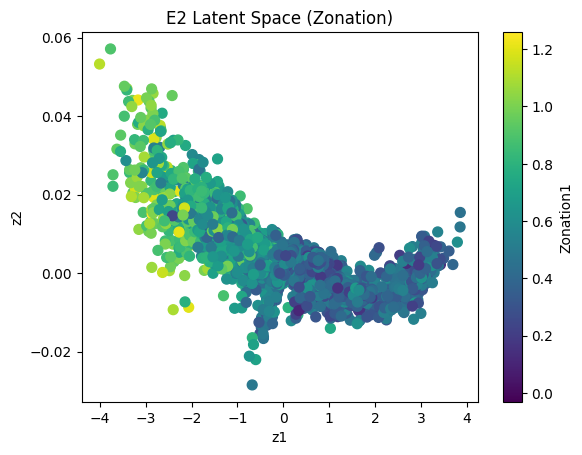

In [23]:
# Split into x and y
x = adata.obsm["component1_e2"][:, 0]
y = adata.obsm["component1_e2"][:, 1]
zonation1 = adata.obs.zonation1.to_numpy()

plt.scatter(x, y, c=zonation1, cmap='viridis', s=50) 
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("E2 Latent Space (Zonation)")
plt.colorbar(label="Zonation1")  # shows color scale
plt.show()

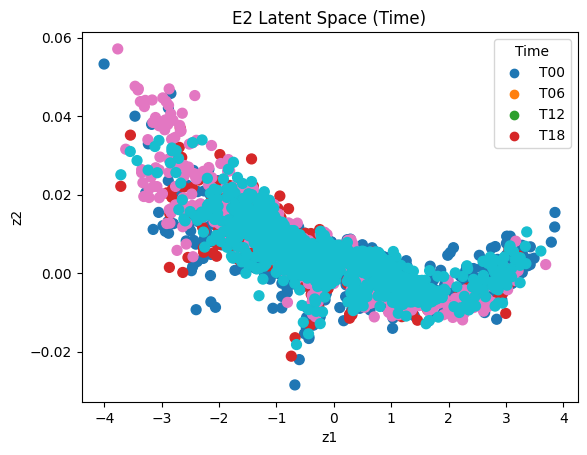

In [26]:
time = adata.obs.time.to_numpy()

# Map each category to an integer
categories = np.unique(time)          # ['T0', 'T1', 'T2']
cat_to_int = {cat:i for i, cat in enumerate(categories)}
colors = np.array([cat_to_int[m] for m in time])

# Plot
plt.scatter(x, y, c=colors, cmap='tab10', s=50)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("E2 Latent Space (Time)")

# Optional: add a legend
for i, cat in enumerate(categories):
    plt.scatter([], [], color=plt.cm.tab10(i), label=cat)
plt.legend(title="Time")
plt.show()

a
b
c


/Users/jeromecho/anaconda3/envs/three-one-zero/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


d


... storing 'rep' as categorical
... storing 'time' as categorical


e
f


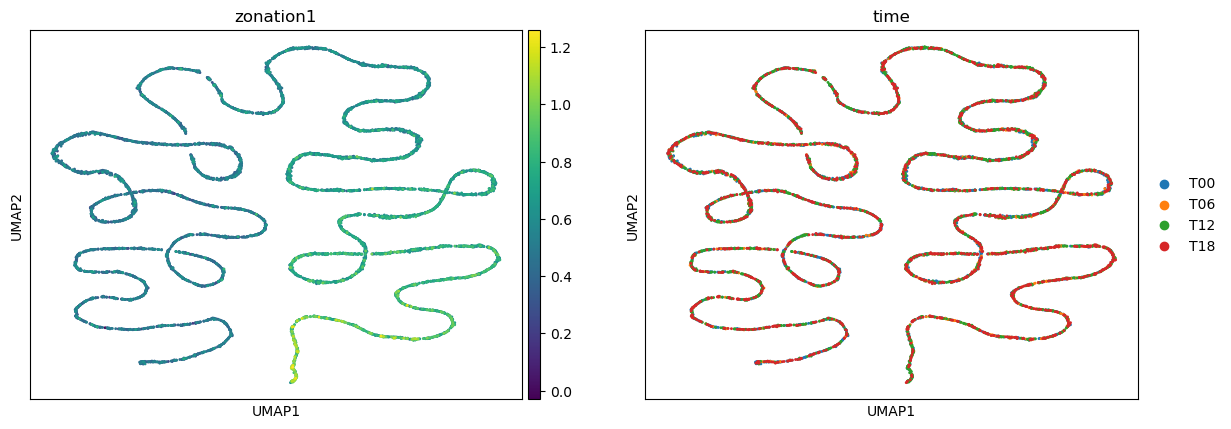

j


In [7]:
compute_umap(adata,
             l_neighbors=50,             # Q: What is this paraeter doing?
             color=['zonation1','time'],
             n_pcs=None, 
             embeddings_key="component1_e2",
             use_original_umap=False,
             palette=None,
             additional_save_information=[],
             title=None,
             save_figure=False)

a
b
c
d
e
f


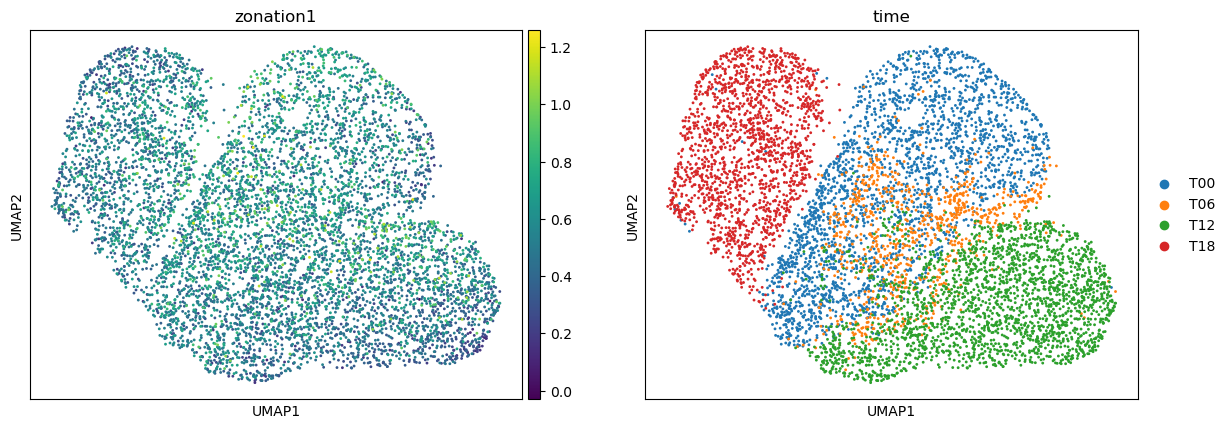

j


In [8]:
compute_umap(adata,
             l_neighbors=50,             # Q: What is this paraeter doing?
             color=['zonation1','time'],
             n_pcs=None, 
             embeddings_key="component2_e10",
             use_original_umap=False,
             palette=None,
             additional_save_information=[],
             title=None,
             save_figure=False)